In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

import maboss
import ginsim 
from tqdm import tqdm

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt # For modifying plots.


In [ ]:
model_ginsim = ginsim.load("Autophagy_and_apoptosis_Sept26.zginml") 
ginsim.show(model_ginsim)

In [3]:
## MaBoSS simulations
model = maboss.loadBNet("../../../model/Autophagy_and_apoptosis_Sept26.bnet")

# Set the default simulation parameters
model.update_parameters(sample_count=2000,max_time=50, time_tick=1, thread_count=8)

# Define custom output phenotype colour mapping
phenotypes_colors = {
    'Apoptosis': 'green',
    'Proliferation': 'red',
    'BECN1': 'blue',
    'Autop_digestion': 'black'
}

# Set the baseline input values for the simulation
BASE_INPUTS = {"AA_Starvation": 0, "Growth_factor": 0, "TNF_R_or_DR": 0, "O_stress": 0,
               "Glucose_starv": 0, "Insuline": 0}

# Set the initial states for the simulation
for nodes in model.network.names:
    if nodes in BASE_INPUTS.keys():
        model.network.set_istate(nodes, [1 - BASE_INPUTS[nodes], BASE_INPUTS[nodes]])
    else:
        model.network.set_istate(nodes, [1,0])

# Define the color palette based on these colours
model.palette = phenotypes_colors

# Set the output nodes for the simulation
model.network.set_output(model.network.names)

In [4]:
# Perform simulation
static_node = ["O_stress","Growth_factor","Insuline",'Glucose_starv',"AA_Starvation","TNF_R_or_DR","Lysosome_prod",'Proliferation','Atphgo_form','Atphgo_mat',"Autop_digestion"
               "Apoptosis"]
target_nodes = list(set(model.network.names)-set(static_node))

In [5]:
# Perform baseline simulation
result = model.run()
df_res = result.get_nodes_probtraj().copy()
df_res['mutation'] = 'wildtype'
df_res['timepoint'] = df_res.index
df_res['mutation_type'] = 'None'

# Store all mutation results
mutation_results = {}
mutation_results['wildtype'] = df_res

# Perturb each target node to OFF one at a time
for i in tqdm(target_nodes):
    #print(f"Mutating {i} to OFF...")
    
    # Create a copy of the model and mutate
    model_mut = maboss.copy_and_mutate(model, [i], "OFF")
    
    # Run simulation
    res_mut = model_mut.run()
    
    # Get probability trajectory
    df_res_mut = res_mut.get_nodes_probtraj().copy()
    df_res_mut['mutation'] = i + '_OFF'
    df_res_mut['timepoint'] = df_res_mut.index
    df_res_mut['mutation_type'] = 'OFF'

    # Store results with mutation name as key
    mutation_results[i + '_OFF'] = df_res_mut

# Perturb each target node to ON one at a time
for i in tqdm(target_nodes):
    #print(f"Mutating {i} to ON...")
    
    # Create a copy of the model and mutate
    model_mut = maboss.copy_and_mutate(model, [i], "ON")
    
    # Run simulation
    res_mut = model_mut.run()
    
    # Get probability trajectory
    df_res_mut = res_mut.get_nodes_probtraj().copy()
    df_res_mut['mutation'] = i + '_ON'
    df_res_mut['timepoint'] = df_res_mut.index
    df_res_mut['mutation_type'] = 'ON'

    # Store results with mutation name as key
    mutation_results[i + '_ON'] = df_res_mut

# Each mutation becomes a separate column or can be accessed individually
print(f"Completed {len(target_nodes)} mutations")
#print(f"Available results: {list(mutation_results.keys())}")

100%|██████████| 109/109 [15:20<00:00,  8.45s/it]

Completed 109 mutations


In [6]:
df_all_mutations = pd.concat(mutation_results.values(), ignore_index=True)
# Filter to only include timepoints from 0 to 40
df_all_mutations = df_all_mutations[(df_all_mutations['timepoint'] >= 0) & (df_all_mutations['timepoint'] <= 40)]
df_all_mutations.to_csv("../../../results/maboss_perturbation_noinput_results.csv", index=False)

## Trajectory comparison of the perturbations (pyPROFILE)

Each perturbation (single node locked ON or OFF, plus the wildtype) is treated as one "model", and the node-probability trajectories are compared with the `trajectory_comparison` module of [pyPROFILE](https://github.com/sysbio-curie/pyPROFILE):

1. `load_trajectories` - format the trajectories (`mutation` -> `model_id`)
2. `pca_trajectory` - project all the states in one PCA space
3. `calculate_distance_matrix` + `calculate_clusters` - DTW distance between whole trajectories, then k-means
4. inspect the clusters and how far each perturbation moves the dynamics away from the wildtype

pyPROFILE is not installed in this environment: only `trajectory_comparison.py` is imported, from the pyPROFILE checkout (it only needs numpy, pandas, scipy, scikit-learn, tqdm, matplotlib and seaborn). Set `PYPROFILE_DIR` to your clone.

In [7]:
import sys

PYPROFILE_DIR = '/Users/saran/Git/pyPROFILE'
sys.path.insert(0, os.path.join(PYPROFILE_DIR, 'pyPROFILE'))
from trajectory_comparison import load_trajectories, TrajectoryComparison

fig_dir = '../../../figures/perturbation_trajectory/'
os.makedirs(fig_dir, exist_ok=True)

### Load and format the trajectories
Reload the saved simulations so that this section can run without re-simulating the perturbations (~1 h). `mutation_type` is not numeric and is dropped from the node columns.

In [8]:
df_all_mutations = pd.read_csv("../../../results/maboss_perturbation_noinput_results.csv")

sim_df = load_trajectories(df_all_mutations, model_col='mutation', time_col='timepoint')
traj = TrajectoryComparison(sim_df)
traj

Non-numeric columns dropped: ['mutation_type']


TrajectoryComparison: 219 models x 41 timepoints x 119 nodes

### PCA of the simulation space

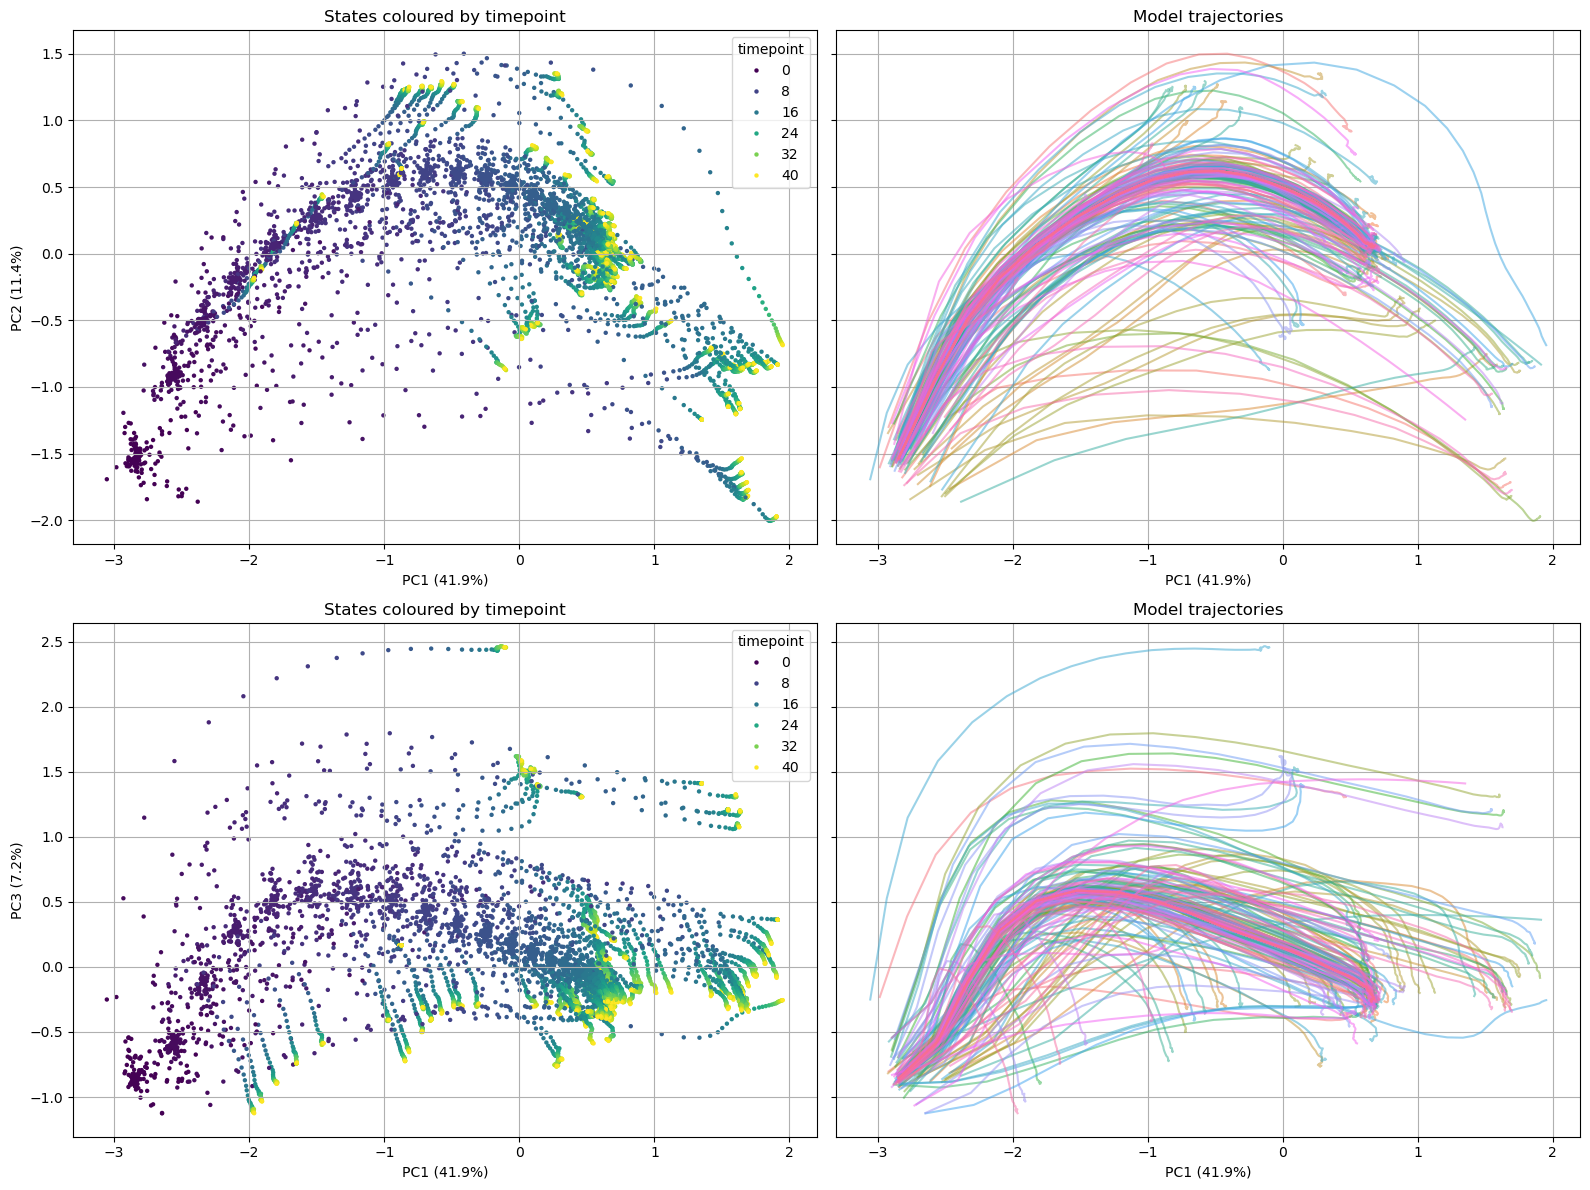

In [9]:
traj.pca_trajectory(n_components=10)
traj.plot_pca_overview(dimension=[(0, 1), (0, 2)], save_fig=fig_dir + 'pca_overview')

#### ON vs OFF perturbations
The trajectories are split into the ON and the OFF perturbations, each with the wildtype. Both subsets keep the PCA fitted on all the states (same axes and limits), so the two plots are directly comparable. The wildtype trajectory is drawn in black.

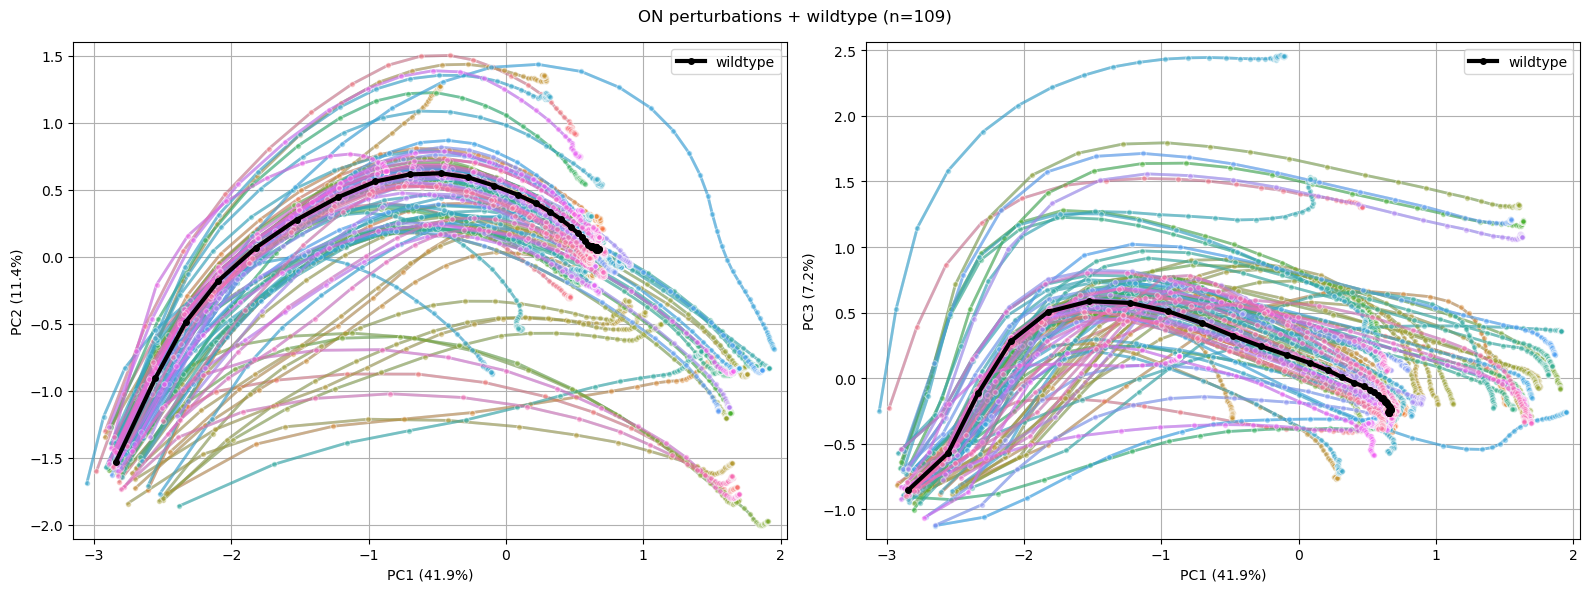

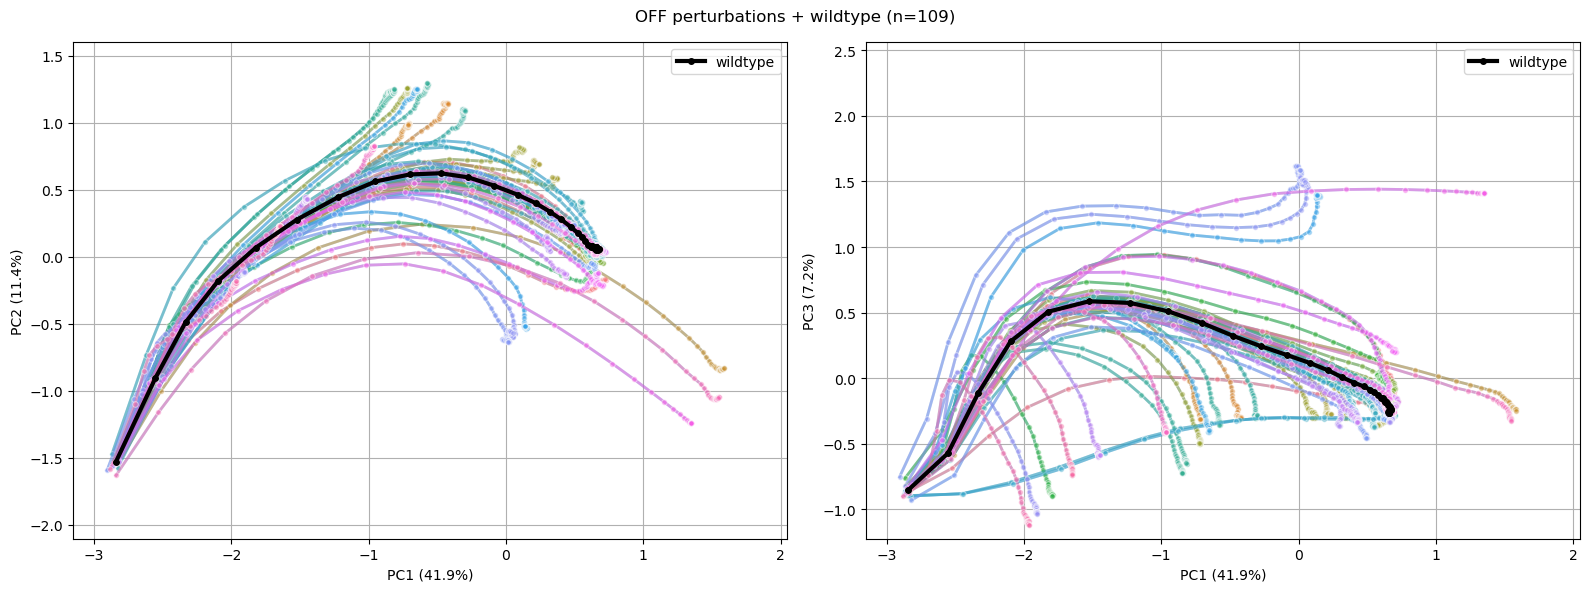

In [10]:
def subset_trajectories(traj, models):
    """TrajectoryComparison restricted to `models`, keeping the PCA (and clusters) computed on all the models."""
    sub = TrajectoryComparison(traj.simulation_df[traj.simulation_df['model_id'].isin(models)])
    sub.pca = traj.pca
    sub.pca_df = traj.pca_df[traj.pca_df['model_id'].isin(models)]
    if hasattr(traj, 'clusters'):
        sub.clusters = traj.clusters.loc[sub.model_list]
        sub.cluster_dict = sub.clusters.to_dict()
    return sub

mutation_type = df_all_mutations.groupby('mutation')['mutation_type'].first()
traj_subsets = {t: subset_trajectories(traj, mutation_type.index[(mutation_type == t) | (mutation_type.index == 'wildtype')])
                for t in ['ON', 'OFF']}

pca_dims = [(0, 1), (0, 2)]
for mut_type, sub in traj_subsets.items():
    fig = sub.plot_pca_trajectory(dimension=pca_dims, size=4, show=False)
    wt = traj.pca_df[traj.pca_df['model_id'] == 'wildtype']
    for ax, (i, j) in zip(fig.axes, pca_dims):
        x, y = f'pc{i + 1}', f'pc{j + 1}'
        ax.plot(wt[x], wt[y], color='black', lw=3, marker='o', markersize=4, label='wildtype')
        ax.set_xlim(traj.pca_df[x].min() - 0.1, traj.pca_df[x].max() + 0.1)
        ax.set_ylim(traj.pca_df[y].min() - 0.1, traj.pca_df[y].max() + 0.1)
        ax.legend(loc='best')
    fig.suptitle(f'{mut_type} perturbations + wildtype (n={len(sub.model_list) - 1})')
    fig.tight_layout()
    fig.savefig(fig_dir + f'pca_trajectory_{mut_type}.png', dpi=600, bbox_inches='tight')
    fig.savefig(fig_dir + f'pca_trajectory_{mut_type}.pdf', bbox_inches='tight')
    plt.show()

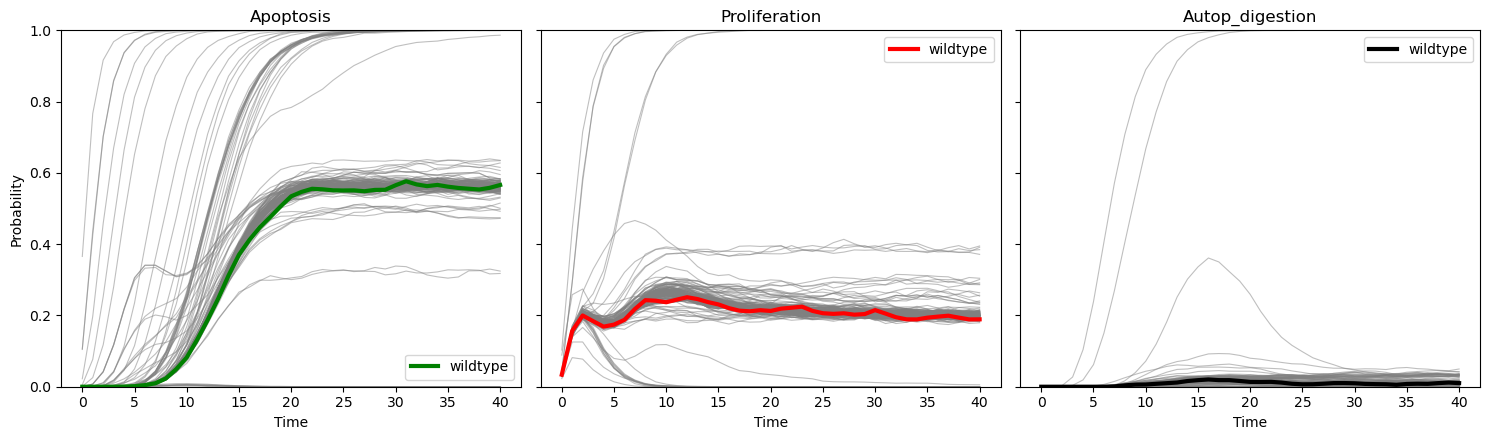

In [11]:
# Set the nodes to plot
nodes_to_plot = ['Apoptosis', 'Proliferation', 'Autop_digestion']

# Define the figure and axes for subplots
fig, axes = plt.subplots(1, len(nodes_to_plot), figsize=(5 * len(nodes_to_plot), 4.5), sharey=True)

# Define the WT condition
wt_sim = traj.simulation_df[traj.simulation_df['model_id'] == 'wildtype']

# For loop to perform the plotting for each node
for ax, node in zip(axes, nodes_to_plot):
    # Individual perturbation trajectories
    for model_id, grp in traj.simulation_df.groupby('model_id'):
        if model_id == 'wildtype':
            continue
        ax.plot(grp['timepoint'], grp[node], color='grey', lw=0.8, alpha=0.5)

    # Wildtype trajectory highlighted
    ax.plot(wt_sim['timepoint'], wt_sim[node], color=phenotypes_colors[node], lw=3, label='wildtype')

    ax.set(xlabel='Time', title=node, ylim=(0, 1))
    ax.legend()

axes[0].set_ylabel('Probability')
fig.tight_layout()
fig.savefig(fig_dir + 'phenotype_perturbation_subplots.png', dpi=300, bbox_inches='tight')
plt.show()

Nodes that vary most across perturbations over time (these drive the separation between trajectories):

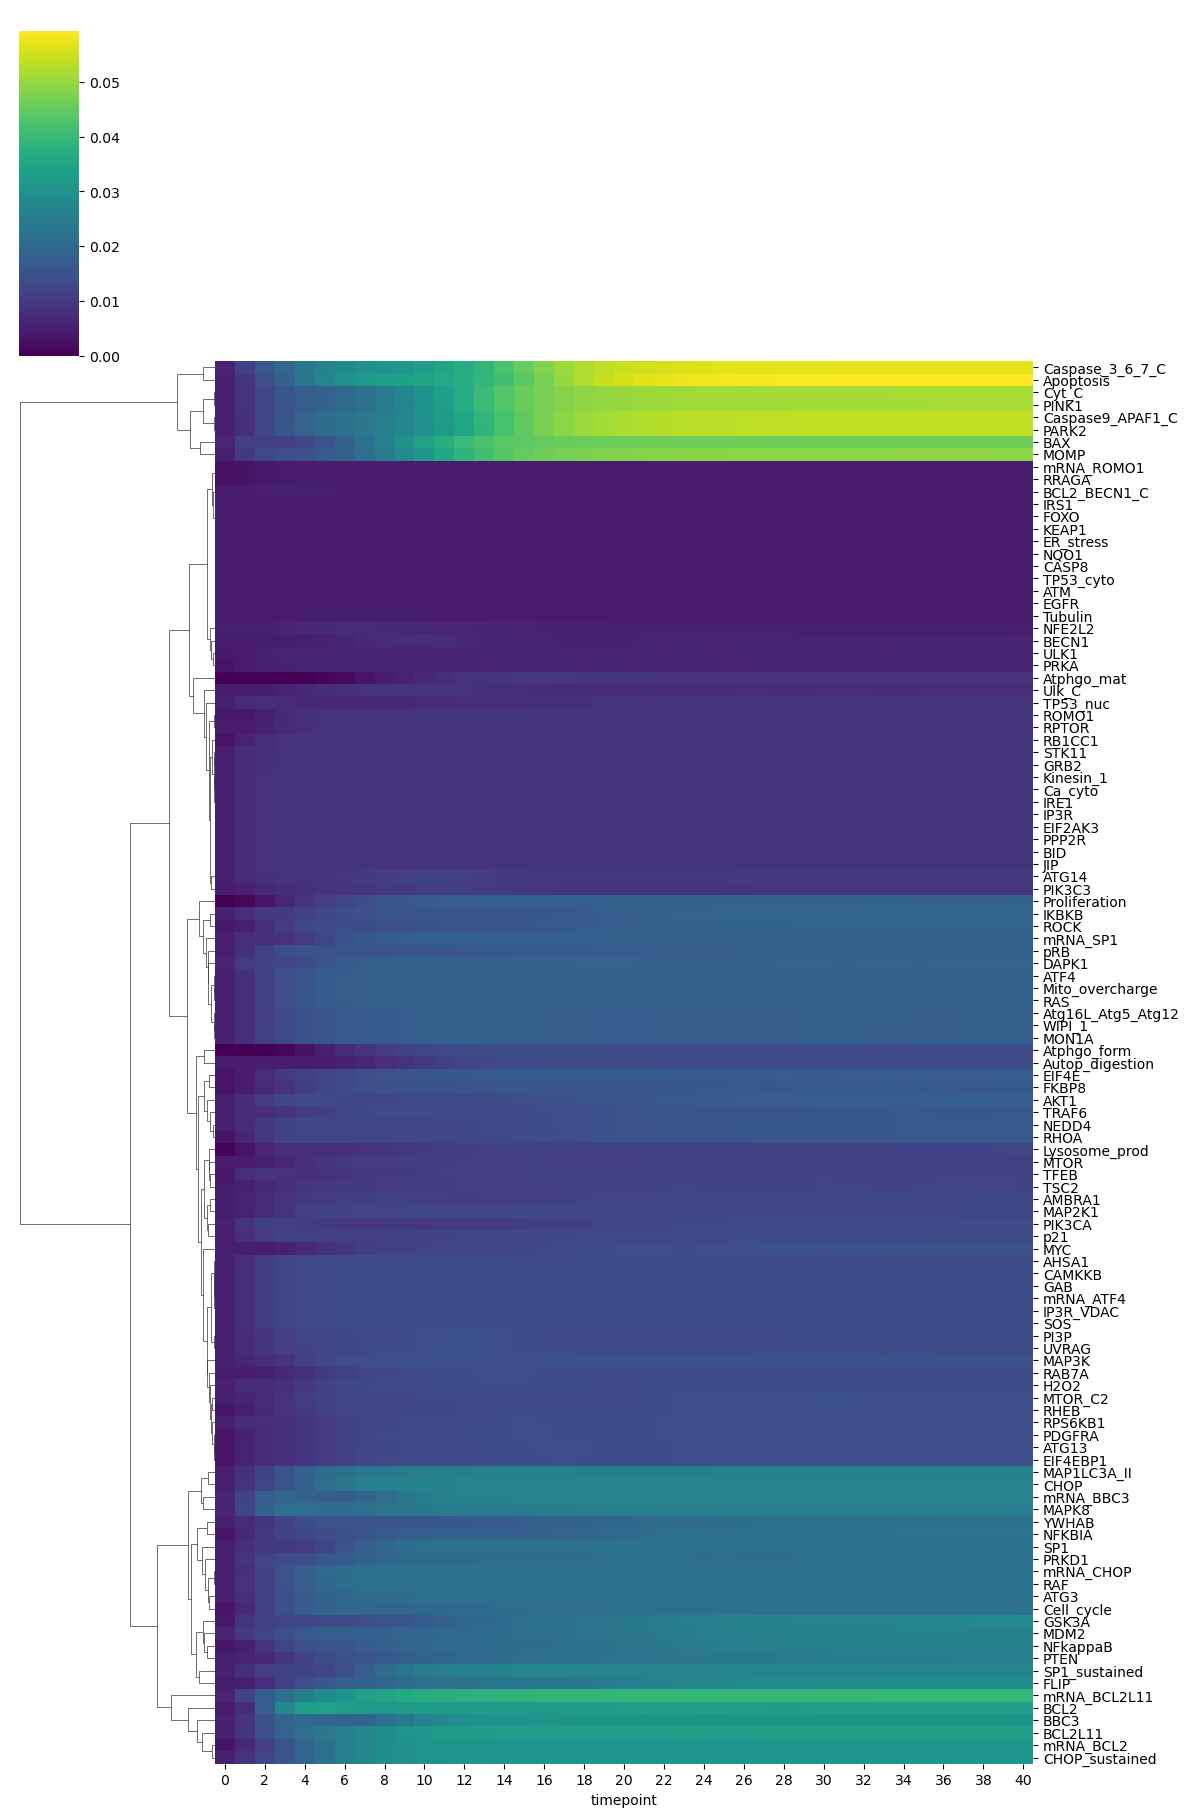

In [12]:
traj.plot_trajectory_variance(save_fig=fig_dir + 'node_variance')

### Trajectory clustering
DTW distance between the whole trajectories (all nodes), then choose the number of clusters from the elbow of the k-means inertia and the silhouette score.

DTW distance:   0%|          | 0/218 [00:00<?, ?it/s]

k-means:   0%|          | 0/10 [00:00<?, ?it/s]

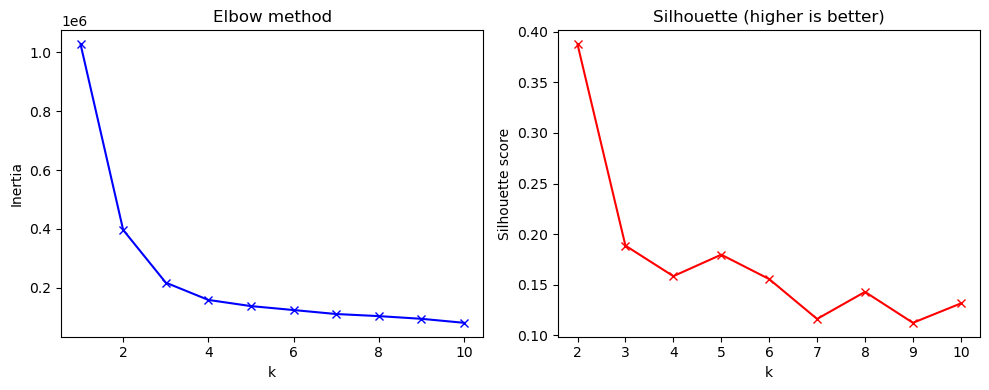

,inertia,silhouette
n_cluster,,
1,1.027629e+06,NaN
2,3.961882e+05,0.387791
3,2.169968e+05,0.188532
4,1.581272e+05,0.158319
5,1.371546e+05,0.179583
6,1.237524e+05,0.155444
7,1.102051e+05,0.115981
8,1.031210e+05,0.142764
9,9.394881e+04,0.112176


In [13]:
traj.calculate_distance_matrix(mode='trajectory')
traj.cluster_elbow_plot(n_cluster=11)

In [15]:
n_cluster = 5  # set from the elbow plot
traj.calculate_clusters(n_cluster=n_cluster)
print(f"wildtype is in cluster {traj.clusters['wildtype']}")
traj.cluster_members()

Calculated kmeans clustering with 5 clusters.
wildtype is in cluster 0


cluster
0    [AHSA1_OFF, AKT1_OFF, ATF4_OFF, ATG13_ON, ATG1...
1    [ATF4_ON, BECN1_ON, CHOP_ON, EGFR_ON, EIF2AK3_...
2    [AKT1_ON, ATM_ON, Atg16L_Atg5_Atg12_ON, BAX_ON...
3    [AHSA1_ON, AMBRA1_OFF, ATG13_OFF, ATG14_ON, AT...
4    [AMBRA1_ON, BBC3_OFF, BCL2_ON, DAPK1_OFF, H2O2...
Name: cluster, dtype: object

### Inspect the clusters
Mean PCA trajectory of each cluster (bold) on top of the individual perturbations:

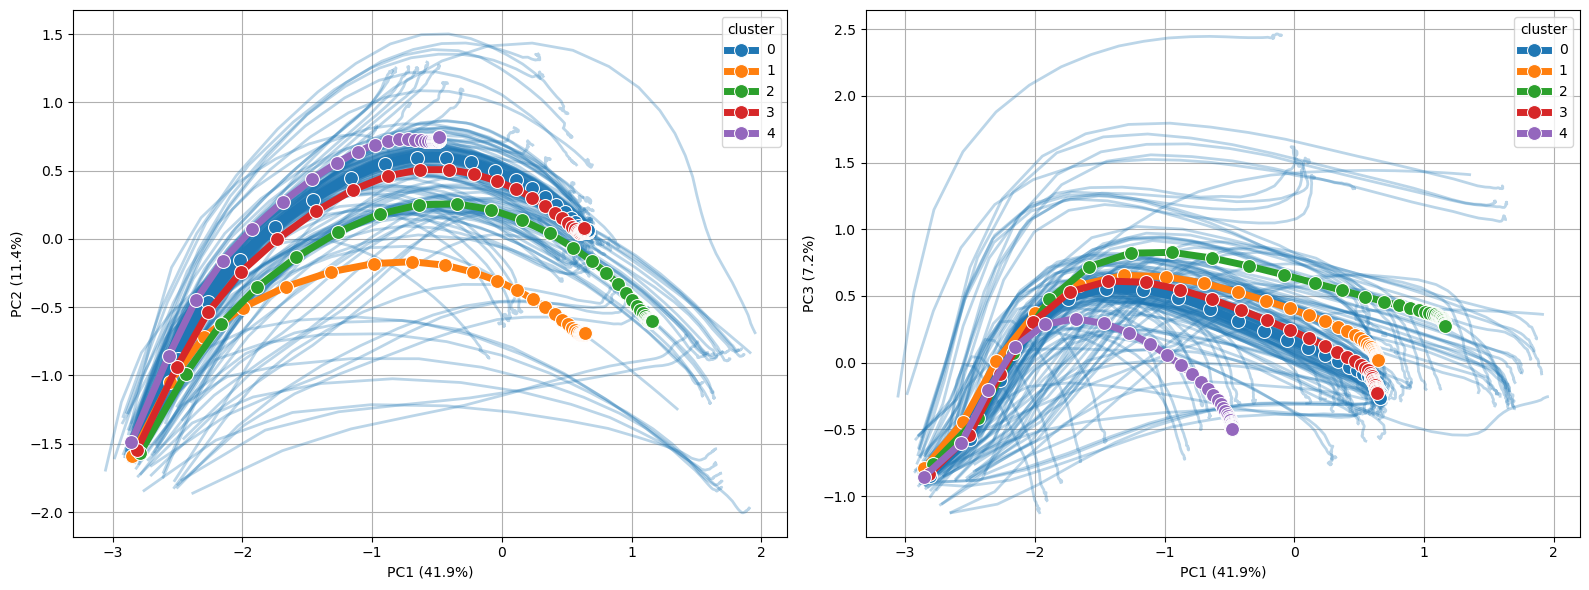

In [16]:
traj.plot_pca_trajectory(dimension=[(0, 1), (0, 2)], plot_cluster=True, save_fig=fig_dir + 'pca_clusters')

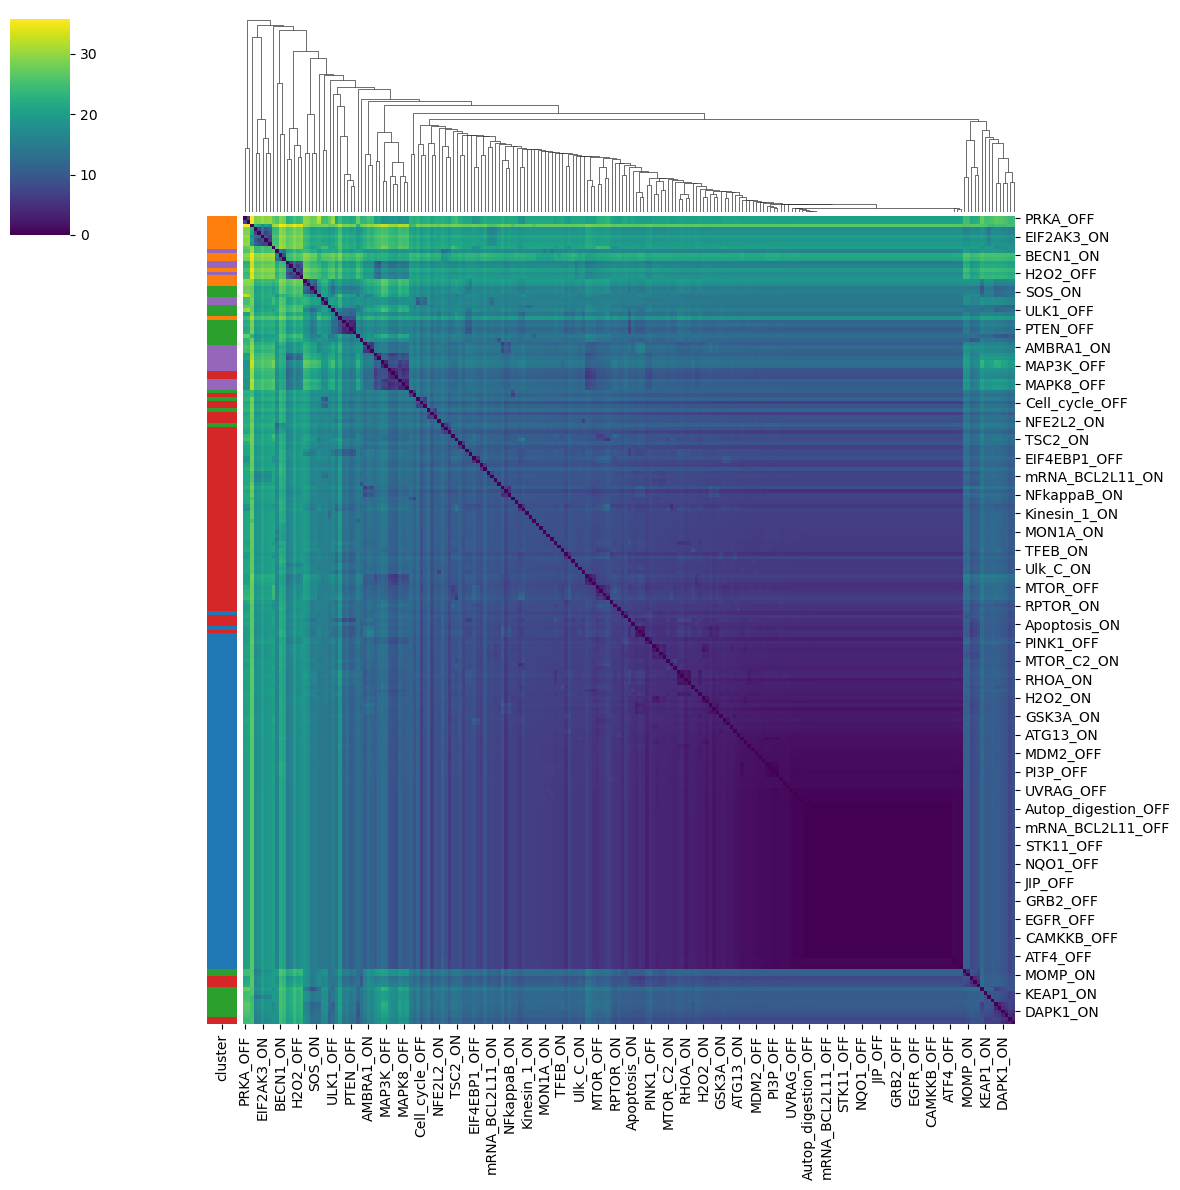

In [17]:
traj.plot_model_distance_space(save_fig=fig_dir + 'dtw_distance_heatmap')

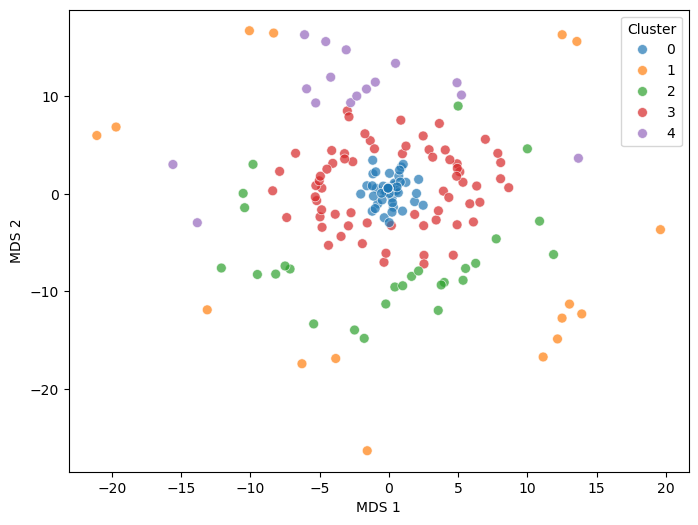

In [18]:
traj.calculate_mds()
traj.plot_mds(plot_cluster=True, save_fig=fig_dir + 'mds_clusters')

Phenotype readouts in each cluster (grey = perturbations, bold = cluster mean):

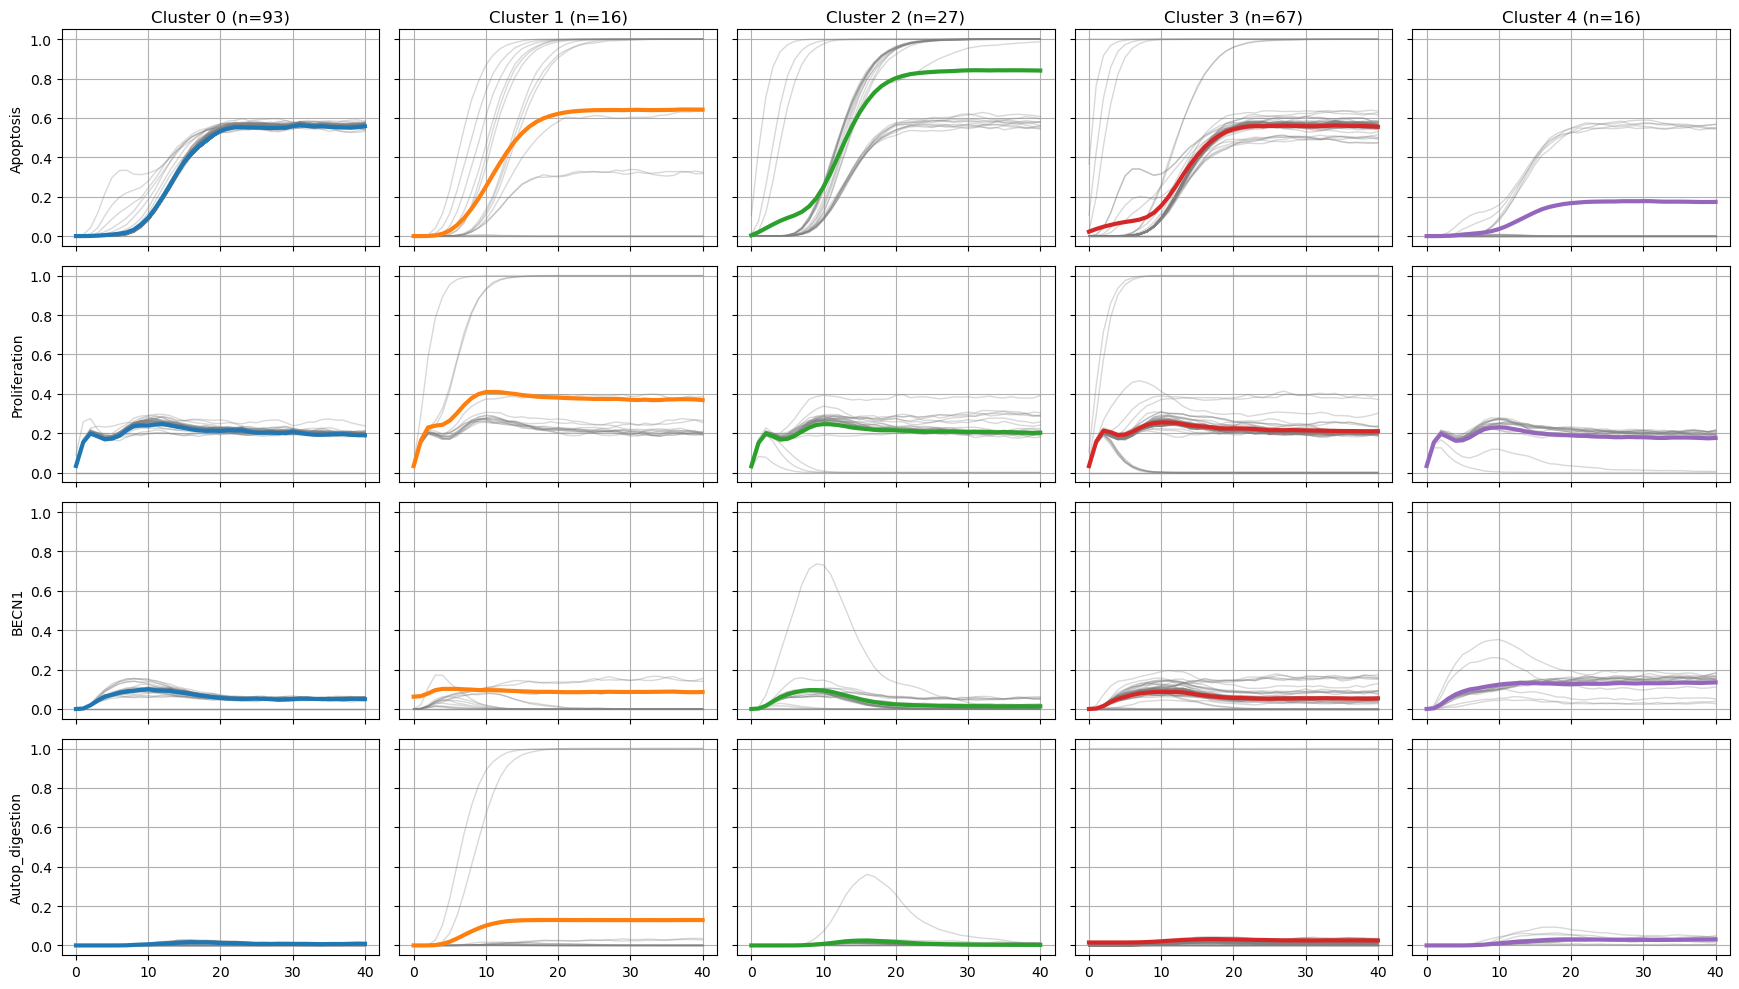

In [19]:
phenotype_nodes = ['Apoptosis', 'Proliferation', 'BECN1', 'Autop_digestion']
traj.plot_node_trajectory(phenotype_nodes, fig_width=3.5, fig_height=2.5, save_fig=fig_dir + 'phenotype_clusters')

In [20]:
# Phenotype probabilities at the last timepoint, per cluster
traj.cluster_mean_trajectory(phenotype_nodes).groupby('cluster').tail(1).round(2)

,,Apoptosis,Proliferation,BECN1,Autop_digestion
cluster,timepoint,,,,
0,40.0,0.56,0.19,0.05,0.01
1,40.0,0.64,0.37,0.09,0.13
2,40.0,0.84,0.20,0.01,0.00
3,40.0,0.56,0.21,0.05,0.02
4,40.0,0.17,0.18,0.13,0.03


### Characterise the clusters
Share of ON / OFF perturbations in each cluster:

In [21]:
pd.crosstab(traj.annotate_models(mutation_type.to_frame())['cluster'], mutation_type)

mutation_type,OFF,ON
cluster,,
0,71,21
1,3,13
2,5,22
3,20,47
4,10,6


Perturbations whose dynamics deviate most from the wildtype (DTW distance to the wildtype trajectory):

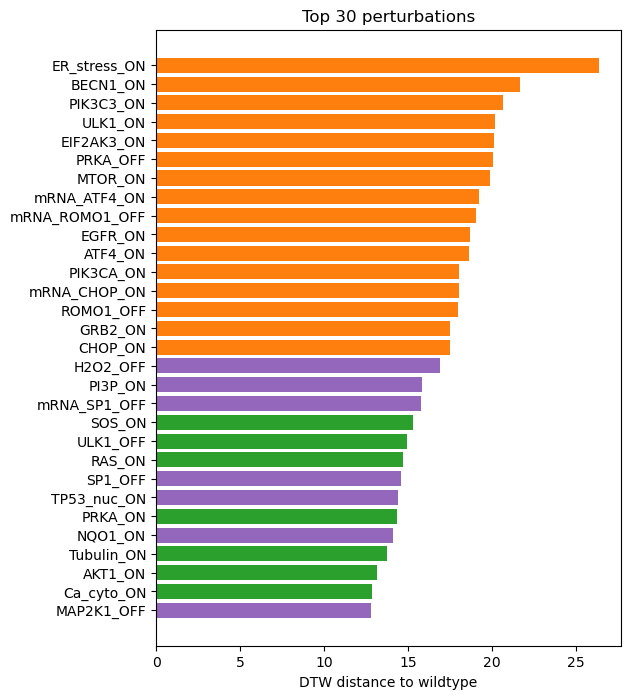

,dtw_to_wildtype,cluster
ER_stress_ON,26.377849,1
BECN1_ON,21.667300,1
PIK3C3_ON,20.662473,1
ULK1_ON,20.179522,1
EIF2AK3_ON,20.097142,1
PRKA_OFF,20.040613,1
MTOR_ON,19.897348,1
mRNA_ATF4_ON,19.246405,1
mRNA_ROMO1_OFF,19.071077,1
EGFR_ON,18.670317,1


In [22]:
dist_to_wt = (traj.annotate_models(traj.distance_matrix[['wildtype']].rename(columns={'wildtype': 'dtw_to_wildtype'}))
              .drop(index='wildtype')
              .sort_values('dtw_to_wildtype', ascending=False))

fig, ax = plt.subplots(figsize=(6, 8))
top = dist_to_wt.head(30)
palette = traj._cluster_palette()
ax.barh(top.index[::-1], top['dtw_to_wildtype'][::-1], color=top['cluster'][::-1].map(palette))
ax.set(xlabel='DTW distance to wildtype', title='Top 30 perturbations')
plt.show()
dist_to_wt.head(30)

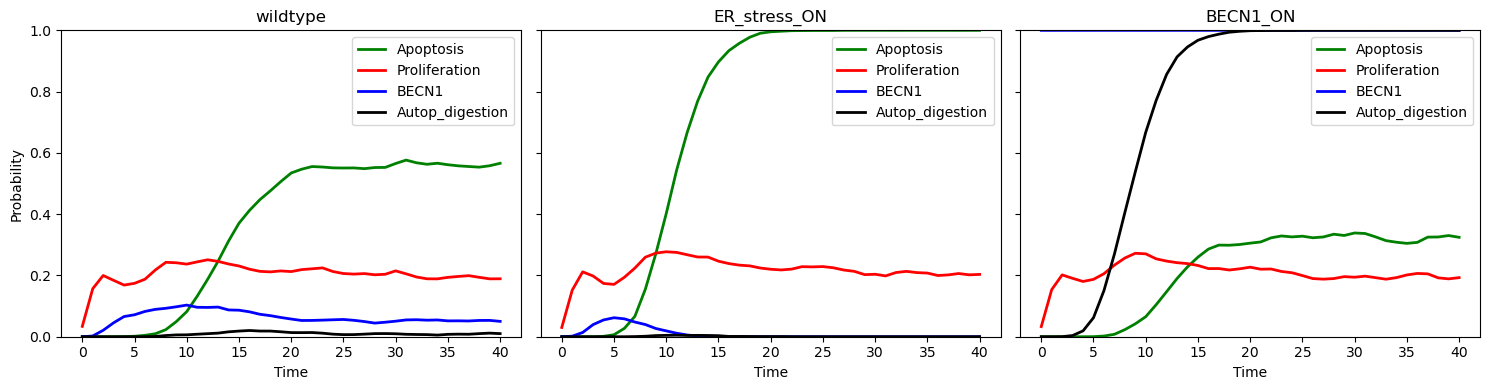

In [24]:
conditions = ['wildtype', 'ER_stress_ON','BECN1_ON']

fig, axes = plt.subplots(1, len(conditions), figsize=(5 * len(conditions), 4), sharey=True)

for ax, cond in zip(axes, conditions):
    sel = traj.simulation_df[traj.simulation_df['model_id'] == cond].set_index('timepoint')
    for node in phenotype_nodes:
        ax.plot(sel.index, sel[node], label=node, color=phenotypes_colors[node], lw=2)
    ax.set(xlabel='Time', title=cond, ylim=(0, 1))
    ax.legend()

axes[0].set_ylabel('Probability')
fig.tight_layout()
fig.savefig(fig_dir + 'phenotype_trajectory_PRKA_ON_vs_wildtype.png', dpi=300, bbox_inches='tight')
plt.show()

### Endpoint-based clustering
Clustering on the last timepoint only, to see what the dynamics add to the final state:

In [25]:
traj_endpoint = TrajectoryComparison(sim_df)
traj_endpoint

TrajectoryComparison: 219 models x 41 timepoints x 119 nodes

In [26]:
traj_endpoint = TrajectoryComparison(sim_df)
traj_endpoint.calculate_distance_matrix(mode='endpoint')
traj_endpoint.calculate_clusters(n_cluster=n_cluster)

pd.crosstab(traj.clusters.rename('trajectory clusters'),
            traj_endpoint.clusters.rename('endpoint clusters'))

Calculated kmeans clustering with 5 clusters.


endpoint clusters,0,1,2,3,4
trajectory clusters,,,,,
0,92,0,1,0,0
1,0,0,0,12,4
2,0,1,14,0,12
3,5,2,60,0,0
4,0,11,0,2,3


In [27]:
traj.clusters.to_csv("../../../results/maboss_perturbation_trajectory_clusters.csv")
dist_to_wt.to_csv("../../../results/maboss_perturbation_dtw_to_wildtype.csv")

### Endpoint in the phenotype space
Level of `Apoptosis`, `Proliferation` and `Autop_digestion` at the last timepoint of each perturbation. Colour = trajectory cluster, marker = ON (▲) / OFF (▼) perturbation, black star = wildtype. The 10 perturbations with the largest DTW distance to the wildtype are labelled.

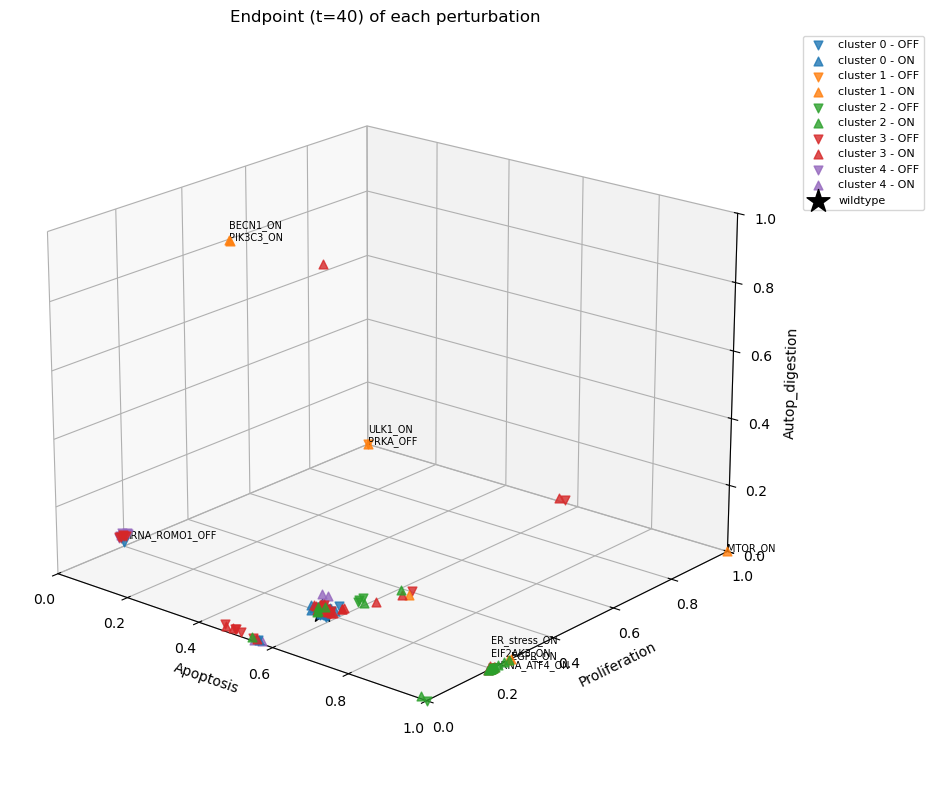

In [ ]:
# Endpoint (last timepoint) of each perturbation in the phenotype space
endpoint_axes = ['Apoptosis', 'Proliferation', 'Autop_digestion']
endpoint_df = (traj.simulation_df.groupby('model_id', sort=False).tail(1)
               .set_index('model_id')[endpoint_axes]
               .join(traj.clusters)
               .join(mutation_type))

fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(projection='3d')
palette = traj._cluster_palette()
markers = {'ON': '^', 'OFF': 'v'}

for (cluster, mut_type), grp in endpoint_df.drop(index='wildtype').groupby(['cluster', 'mutation_type']):
    ax.scatter(grp['Apoptosis'], grp['Proliferation'], grp['Autop_digestion'],
               color=palette[cluster], marker=markers[mut_type], s=40, alpha=0.8, depthshade=False,
               label=f'cluster {cluster} - {mut_type}')

# Wildtype highlighted
wt_end = endpoint_df.loc['wildtype']
ax.scatter(wt_end['Apoptosis'], wt_end['Proliferation'], wt_end['Autop_digestion'],
           color='black', marker='*', s=300, depthshade=False, label='wildtype')

# Label the 10 perturbations whose trajectory deviates most from the wildtype
# (perturbations ending at about the same point share one label)
top_endpoints = endpoint_df.loc[dist_to_wt.head(10).index, endpoint_axes]
for _, grp in top_endpoints.groupby([top_endpoints[c].round(1) for c in endpoint_axes]):
    x, y, z = grp.mean()
    ax.text(x, y, z, '\n'.join(grp.index), fontsize=7)

ax.set(xlabel='Apoptosis', ylabel='Proliferation', zlabel='Autop_digestion',
       xlim=(0, 1), ylim=(0, 1), zlim=(0, 1),
       title=f"Endpoint (t={traj.simulation_df['timepoint'].max():g}) of each perturbation")
ax.view_init(elev=20, azim=-50)
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=8)
fig.tight_layout()
fig.savefig(fig_dir + 'endpoint_phenotype_3d.png', dpi=300, bbox_inches='tight')
fig.savefig(fig_dir + 'endpoint_phenotype_3d.pdf', bbox_inches='tight')
plt.show()